## airsim_dataset.py

In [1]:
import os
import json
from PIL import Image
from scipy.ndimage import gaussian_filter

import cv2
import numpy as np
import torch

from vision_process import process_vision_info
from orthography import Orthophoto
from dataset.vis_data import visualize_waypoints


In [2]:
video_frame_num = 5
target_interval = 30
data_list_json_paths = ["../data/train_data_sample.json"]
visualize = False
sigma = 20
visual_prompt = True

data_list = []
for file in data_list_json_paths:
    with open(file, "r") as f:
        datum = json.load(f)
    data_list += datum

data = data_list

ortho_processor = Orthophoto(granularity=0.3)

idx = 5

In [3]:
def preprocess(image, pad_color=(0, 0, 0)):
    img_size = 784
    h, w = image.shape[:2]
    scale = img_size * 1.0 / max(h, w)
    new_h, new_w = h * scale, w * scale
    new_w = int(new_w + 0.5)
    new_h = int(new_h + 0.5)
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    resized_hw = (new_h, new_w)

    pad_h = img_size - new_h
    pad_w = img_size - new_w
    padded_image = cv2.copyMakeBorder(resized_image, 0, pad_h, 0, pad_w,
                                    cv2.BORDER_CONSTANT, value=pad_color)
    return padded_image, resized_hw

def generate_prob_message_v2(pil_image, description):
    visual_prompt = True
    if isinstance(pil_image, np.ndarray):
        pil_image = Image.fromarray(pil_image)
    if isinstance(description, list):
        description = description[0]
    text_parts = description.split("The description of the target and its surrounding is shown below.")
    direction = text_parts[0].strip().split("Compass north corresponds to the top of the bird's-eye-view image.")[-1]
    direction = direction.strip()
    object_description = text_parts[-1].strip()

    prob_message = [{
        'role':'user',
        'content':[
            {'type':'image', 'image':pil_image},
            {'type':'text', 'text': "Task: Predict the probability distribution of the drone's future flight locations to search for the target."
            "Input Image: The image is an orthophoto map generated from the drone's past flight trajectory."},
            {'type':'text', 'text': "The green dots indicate past drone positions." if visual_prompt else " "},
            {'type':'text', 'text': "The top of the image corresponds to the north in the world coordinate system.\n" 
            f"Target Information: {direction}"
            f"The description of the target and its surrounding is shown below: {object_description}\n"
            "Objective: "
            "Analyze the provided orthophoto map and target information."
            "Predict the next flight location for the drone that maximize the probability of finding the target."
            "Output a probability map, indicating the likelihood of different regions in the orthophoto map being the optimal next flight destinations."
            }
        ]
    },
    {
        'role':'assistant',
        'content':[
            {'type':'image', 'image':pil_image}
        ]
    }
    ]
    return prob_message
    
def gaussian(target, img_size):
    sigma = 20
    h, w = img_size
    prob_map = np.zeros((h, w), dtype=np.float32)
    i, j = target
    i, j = min(round(i),h-1), min(round(j),w-1)
    prob_map[i, j] = 1
    i_1 = min(h-1, i+1)
    j_1 = min(w-1, j+1)
    i_2 = max(0, i-1)
    j_2 = max(0, j-1)
    prob_map[i, j_1] = 1
    prob_map[i, j_2] = 1
    prob_map[i_1, j] = 1
    prob_map[i_2, j] = 1

    sigma = max(h,w) // 25 if sigma is None else sigma
    prob_map = gaussian_filter(prob_map, sigma=sigma)
    return prob_map

def get_prob_map(ortho, coor_map, end, ortho_depth=None, delta_height=None):
    h, w = ortho.shape[:2]
    if ortho_depth is not None:
        depth_mask = (ortho_depth > delta_height).reshape(h,w)
    i, j = ortho_processor.world_to_pixel(end, coor_map=coor_map)
    i, j = min(max(round(i), 0), h-1), min(max(round(j), 0), w-1)
    prob_map_0 = np.zeros((h, w))
    prob_map_0[i, j] = 1

    yy, xx = np.ogrid[:h, :w]
    distances = np.sqrt((yy - i)**2 + (xx - j)**2)
    max_dist = np.sqrt(2*(h-1)**2)
    prob_map_0 = 1 - distances / max_dist
    prob_map_0[~depth_mask] = 0

    new_i, new_j = np.unravel_index(np.argmax(prob_map_0), (h, w))
    prob_map = gaussian((new_i, new_j), (h, w))
    # prob_map[~depth_mask] = 0
    prob_map = prob_map / (np.max(prob_map) + 1e-6)

    return prob_map, depth_mask

In [4]:
data_info = data[idx]
traj_dir = data_info["traj_folder_path"]
depth_dir = os.path.join(traj_dir, "bevcamera_depth")
image_dir = os.path.join(traj_dir, "bevcamera")
log_dir = os.path.join(traj_dir, "log")
image_path = data_info["image_path"]

high_uav_pos_now = data_info["high_uav_pos_now"]
end_pos = data_info["end_pos"]
int_time = data_info["int_time"]
target_time = int_time+target_interval

description_path = os.path.join(traj_dir, "object_description_with_help.json")
with open(description_path, 'r') as f:
    description = json.load(f)
description = description[0]

image_files = sorted([f for f in os.listdir(image_dir)])
image_numbers = sorted([int(f.split('.')[0]) for f in image_files])
available_images = [t for t in image_numbers if t <= int_time]
available_num = len(available_images)
if available_num > video_frame_num:
    indices = [round(i * (available_num - 1) / (video_frame_num - 1)) for i in range(video_frame_num)]
    available_images = [available_images[i] for i in indices]
names = [f"{t:06d}" for t in available_images]

# historial orthography
frame_paths = [os.path.join(image_dir, f"{idx}.png") for idx in names]
log_paths = [os.path.join(log_dir, f"{idx}.json") for idx in names]
depth_paths = [os.path.join(depth_dir, f"{idx}.png") for idx in names]
positions = np.array([
            json.load(open(log_path, "r"))["sensors"]["state"]["position"] for log_path in log_paths
            ])
frames = np.array([cv2.imread(frame_path) for frame_path in frame_paths])
depths = np.array([cv2.imread(depth_path, cv2.IMREAD_UNCHANGED) for depth_path in depth_paths])

coord_3d_clouds = ortho_processor.project_images_to_3d(depths, positions)
merged_ortho, coor_map, merged_depth = ortho_processor.orthorectify(frames, coord_3d_clouds, depths)
merged_ortho = cv2.cvtColor(merged_ortho, cv2.COLOR_BGR2RGB)

In [5]:
with open(os.path.join(traj_dir, "gt_waypoints.json"), "r") as f:
    gt_waypoints = json.load(f)
if len(gt_waypoints) > len(image_numbers):
    indices = [round(i * (len(gt_waypoints) - 1) / (len(image_numbers) - 1)) for i in range(len(image_numbers))]
else:
    indices = [i for i in range(len(gt_waypoints))]
index = image_numbers.index(int_time)
time_now = indices[index]
time_target = time_now + target_interval
waypoint_now = gt_waypoints[time_now]
if time_target < len(gt_waypoints):
    waypoint_target = gt_waypoints[time_target]
else:
    waypoint_target = end_pos
if visual_prompt:
    time_indexs = indices[:index]
    vis_waypoints = [gt_waypoints[n] for n in time_indexs]
    merged_ortho_prob = visualize_waypoints(vis_waypoints, coor_map, merged_ortho)
else:
    merged_ortho_prob = merged_ortho
prob_map, depth_mask = get_prob_map(merged_ortho, coor_map, waypoint_target, 
                                    ortho_depth=merged_depth, delta_height=waypoint_now[2]-high_uav_pos_now[2])
ortho_resize_pad, resized_hw = preprocess(merged_ortho_prob)
prob_map, _ = preprocess(prob_map)
depth_mask = depth_mask.astype(np.uint8)
depth_mask, _ = preprocess(depth_mask)
prob_message = generate_prob_message_v2(ortho_resize_pad, description)

prob_map = torch.from_numpy(prob_map)
prob_map = prob_map.unsqueeze(0)

In [6]:
batch = {
            "prob_message": prob_message,
            "prob_map": prob_map.float(),
            "target_time": target_time,
            "traj_dir": traj_dir,
        }

In [7]:
batch['traj_dir']

'../data/Hal-13k/Carla_Town10HD/62a365ab-6b00-462c-b092-8b264bf319a8'

## Collate_fn

In [8]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch
from torch.utils.data import DataLoader
from functools import partial


cache_path = "./weights/huggingface"
model_path = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"
processor = AutoProcessor.from_pretrained(model_path, cache_dir=cache_path)
model = AutoModelForImageTextToText.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    _attn_implementation="flash_attention_2",
    cache_dir=cache_path
).to("cuda")

/storage/project/r-cj124-0/sibidapo3/anxcnda/aeroduo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:10<00:00,  5.40s/it]


In [9]:
masks_list = []
messages_list = []
traj_folders = []
target_times = []

for data in [batch]:
    masks_list.append(data["prob_map"])
    message = data["prob_message"]
    messages_list.append(message)
    traj_folders.append(data["traj_dir"])
    target_times.append(data["target_time"])

texts = [processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=False) for msg in messages_list]
image_inputs, video_inputs = process_vision_info(messages_list)

inputs = processor(
        text=texts,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

In [10]:
list(inputs.keys())

['pixel_values', 'pixel_attention_mask', 'input_ids', 'attention_mask']

In [11]:
inputs['pixel_values'].shape

torch.Size([1, 34, 3, 384, 384])

In [12]:
image_inputs

[<PIL.Image.Image image mode=RGB size=784x784>,
 <PIL.Image.Image image mode=RGB size=784x784>]

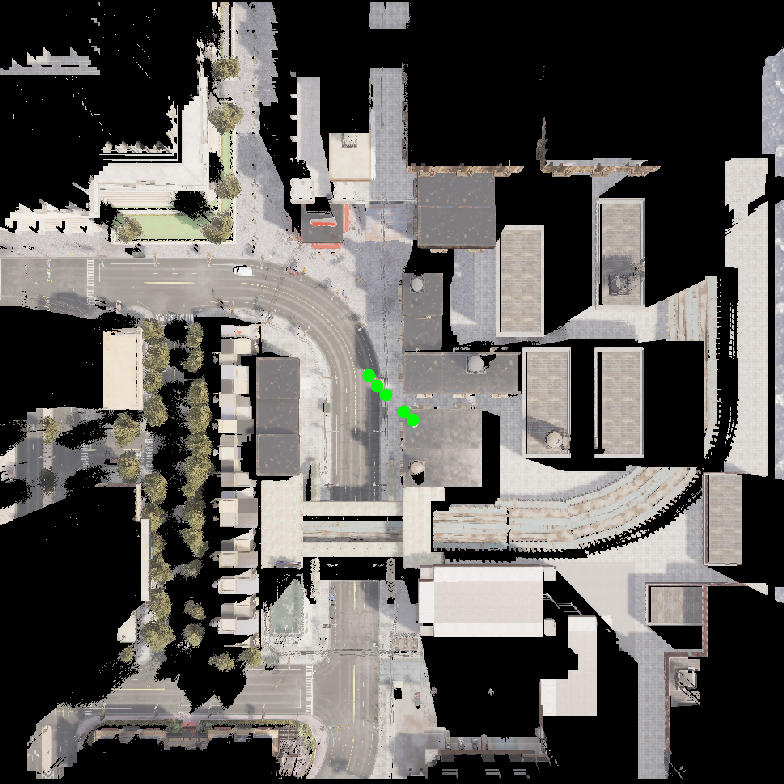

In [13]:
image_inputs[0]

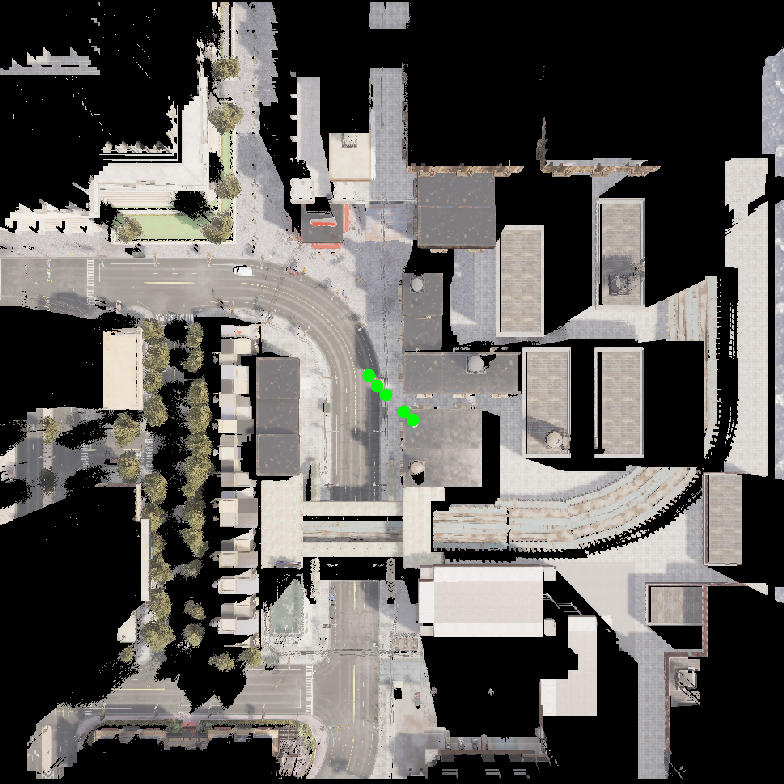

In [14]:
image_inputs[1]

In [15]:
input_ids_lists = inputs['input_ids'].tolist()
len(input_ids_lists[0])

3051

In [16]:
messages_list

[[{'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=784x784>},
    {'type': 'text',
     'text': "Task: Predict the probability distribution of the drone's future flight locations to search for the target.Input Image: The image is an orthophoto map generated from the drone's past flight trajectory."},
    {'type': 'text', 'text': 'The green dots indicate past drone positions.'},
    {'type': 'text',
     'text': 'The top of the image corresponds to the north in the world coordinate system.\nTarget Information: The target location is 40.81 degrees north by west from the starting point.The description of the target and its surrounding is shown below: The man is walking on a sidewalk next to a street with visible shadows from overhead power lines, surrounded by a mix of low and mid-rise buildings, including a construction site and a series of shops and cafes, in an urban area with roads lined by parked cars and trees.\nObjective: Analyze 

In [17]:
texts

["<|im_start|>User:<image>Task: Predict the probability distribution of the drone's future flight locations to search for the target.Input Image: The image is an orthophoto map generated from the drone's past flight trajectory.The green dots indicate past drone positions.The top of the image corresponds to the north in the world coordinate system.\nTarget Information: The target location is 40.81 degrees north by west from the starting point.The description of the target and its surrounding is shown below: The man is walking on a sidewalk next to a street with visible shadows from overhead power lines, surrounded by a mix of low and mid-rise buildings, including a construction site and a series of shops and cafes, in an urban area with roads lined by parked cars and trees.\nObjective: Analyze the provided orthophoto map and target information.Predict the next flight location for the drone that maximize the probability of finding the target.Output a probability map, indicating the likel

In [18]:
processor.tokenizer.encode("\nAssistant:")

[198, 9519, 9531, 42]

In [19]:
processor.tokenizer.encode("<end_of_utterance>\n")

[49279, 198]

In [20]:
labels_ids = [-100] * len(input_ids_lists[0])
labels_ids

[-100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,

In [62]:
processor

SmolVLMProcessor:
- image_processor: SmolVLMImageProcessor {
  "do_convert_rgb": true,
  "do_image_splitting": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "SmolVLMImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "max_image_size": {
    "longest_edge": 384
  },
  "processor_class": "SmolVLMProcessor",
  "resample": 1,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1536
  },
  "video_sampling": {
    "fps": 1,
    "max_frames": 64,
    "video_size": {
      "longest_edge": 384
    }
  }
}

- tokenizer: GPT2TokenizerFast(name_or_path='HuggingFaceTB/SmolVLM2-2.2B-Instruct', vocab_size=49152, model_max_length=16384, is_fast=True, padding_side='right', truncation_side='left', special_tokens={'bos_token': '<|im_start|>', 'eos_token': '<end_of_utterance>', 'unk_token': '<|endoftext|>', 'pad_token': '<|im_end|>', 'additional_specia

## Train pilot_llm

In [21]:
import argparse
import math
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'true'
from functools import partial
import time
import shutil

import datasets
import torch
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import set_seed
from functools import partial
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from peft import get_peft_model, LoraConfig, PeftModel

from torch.utils.tensorboard import SummaryWriter

import transformers
from transformers import SchedulerType, get_scheduler
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.utils import check_min_version, send_example_telemetry
from transformers.utils.versions import require_version
from dataset_smolvlm.airsim_dataset import AirSimDataset, collate_fn


In [22]:
check_min_version("4.53.0")

logger = get_logger(__name__)

require_version("datasets>=2.0.0", "To fix: pip install -r examples/pytorch/semantic-segmentation/requirements.txt")

In [23]:
def parse_args():
    parser = argparse.ArgumentParser(description="Finetune a transformers model on a image semantic segmentation task")
    parser.add_argument(
        "--model_name_or_path",
        type=str,
        help="Path to a pretrained model or model identifier from huggingface.co/models.",
        default="HuggingFaceTB/SmolVLM2-2.2B-Instruct"
    )
    parser.add_argument(
        "--cache_path",
        type=str,
        help="default saved location of model if downloading",
        default="./weights/huggingface"
    )
    parser.add_argument(
        "--dataset_name",
        type=str,
        help="Name of the dataset on the hub",
        default=["../data/train_data_sample.json"],
    )
    parser.add_argument(
        "--reload_model_path",
        help="Name of the dataset on the hub.",
        default=None
    )
    parser.add_argument( #########TODO#############
        "--num_token",
        type=int,
        default=784
    )
    parser.add_argument(
        "--mission",
        default="prob"
    )
    parser.add_argument(
        "--output_dir", 
        type=str, 
        help="Where to store the final model.",
        default="model_output"
    )
    parser.add_argument(
        "--lora",
        type=bool,
        help="if use lora to train",
        default=True,
    )
    parser.add_argument(
        "--lora_target_modules",
        type=list,
        default=['down_proj','o_proj','k_proj','q_proj','gate_proj','up_proj','v_proj']
    )
    parser.add_argument(
        "--per_device_train_batch_size",
        type=int,
        default=5,
        help="Batch size (per device) for the training dataloader.",
    )
    parser.add_argument(
        "--mixed_precision",
        type=str,
        default="bf16",
        help="",
    )
    parser.add_argument(
        "--learning_rate",
        type=float,
        default=5e-5,
        help="Initial learning rate (after the potential warmup period) to use.",
    )
    parser.add_argument(
        "--adam_beta1",
        type=float,
        default=0.9,
        help="Beta1 for AdamW optimizer",
    )
    parser.add_argument(
        "--adam_beta2",
        type=float,
        default=0.999,
        help="Beta2 for AdamW optimizer",
    )
    parser.add_argument(
        "--adam_epsilon",
        type=float,
        default=1e-8,
        help="Epsilon for AdamW optimizer",
    )
    parser.add_argument(
        "--num_train_epochs",
        type=int,
        default=3,
        help="Total number of training epochs to perform."
    )
    parser.add_argument(
        "--max_train_steps",
        type=int,
        default=10000,
        help="Total number of training steps to perform. If provided, overrides num_train_epochs.",
    )
    parser.add_argument( #########TODO#############
        "--gradient_accumulation_steps",
        type=int,
        default=1,
        help="Number of updates steps to accumulate before performing a backward/update pass.",
    )
    parser.add_argument(
        "--lr_scheduler_type",
        type=SchedulerType,
        default="cosine",
        help="The scheduler type to use.",
        choices=["linear", "cosine", "cosine_with_restarts", "polynomial", "constant", "constant_with_warmup"],
    )
    parser.add_argument(
        "--num_warmup_steps", type=int, default=0, help="Number of steps for the warmup in the lr scheduler."
    )
    parser.add_argument("--seed", type=int, default=None, help="A seed for reproducible training.")
    parser.add_argument(
        "--checkpointing_steps",
        type=str,
        default=1000,
        help="Whether the various states should be saved at the end of every n steps, or 'epoch' for each epoch.",
    )
    parser.add_argument(
        "--checkpoints_total_limit",
        type=int,
        default=3,
        help=""
    )
    parser.add_argument(
        "--resume_from_checkpoint",
        type=str,
        default=None,
        help="If the training should continue from a checkpoint folder.",
    )
    args, _ = parser.parse_known_args()

    if args.output_dir is not None:
        os.makedirs(args.output_dir, exist_ok=True)

    return args


In [24]:
import sys
sys.argv = ["ipykernel_launcher.py"]  # strip Jupyter-injected args

In [25]:
## def main

args = parse_args()

send_example_telemetry("run_semantic_segmentation_no_trainer", args)

accelerator = Accelerator(gradient_accumulation_steps=args.gradient_accumulation_steps,
                          mixed_precision=args.mixed_precision)

logger.info(accelerator.state, main_process_only=False)
if accelerator.is_local_main_process:
    datasets.utils.logging.set_verbosity_warning()
    transformers.utils.logging.set_verbosity_info()
else:
    datasets.utils.logging.set_verbosity_error()
    transformers.utils.logging.set_verbosity_error()

# If passed along, set the training seed now.
# We set device_specific to True as we want different data augmentation per device.
if args.seed is not None:
    set_seed(args.seed, device_specific=True)

if accelerator.is_main_process:
    if args.output_dir is not None:
        os.makedirs(args.output_dir, exist_ok=True)
accelerator.wait_for_everyone()


current_time = time.strftime("%Y%m%d-%H%M%S", time.localtime())
log_dir = os.path.join(args.output_dir, current_time)
tb_writer = SummaryWriter(log_dir=log_dir)

weight_dtype = torch.float32
if accelerator.mixed_precision == "fp16":
    weight_dtype = torch.float16
    args.mixed_precision = accelerator.mixed_precision
elif accelerator.mixed_precision == "bf16":
    weight_dtype = torch.bfloat16
    args.mixed_precision = accelerator.mixed_precision

processor = AutoProcessor.from_pretrained(args.model_name_or_path, cache_dir=args.cache_path, padding_side="right")
model = AutoModelForImageTextToText.from_pretrained( #####TODO: To be replaced by smolpilotllm####
    args.model_name_or_path,
    _attn_implementation="flash_attention_2",
    cache_dir=args.cache_path
    )

# load pretrain model（seg and depth pretraining
if args.reload_model_path is not None:
    model = PeftModel.from_pretrained(model, args.reload_model_path)
    weights = torch.load(os.path.join(args.reload_model_path, "pytorch_model/mp_rank_00_model_states.pt"))
    model.load_state_dict(weights['module'], strict=False)

    # If loading a trained main model, do not rewrite a set of lora
    model = model.merge_and_unload()
    if accelerator.is_main_process:
        del weights

if args.lora:
    lora_config = LoraConfig(
        r=8,
        target_modules=args.lora_target_modules,
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, lora_config)

loading configuration file processor_config.json from cache at ./weights/huggingface/models--HuggingFaceTB--SmolVLM2-2.2B-Instruct/snapshots/482adb537c021c86670beed01cd58990d01e72e4/processor_config.json
loading configuration file preprocessor_config.json from cache at ./weights/huggingface/models--HuggingFaceTB--SmolVLM2-2.2B-Instruct/snapshots/482adb537c021c86670beed01cd58990d01e72e4/preprocessor_config.json
Image processor SmolVLMImageProcessor {
  "do_convert_rgb": true,
  "do_image_splitting": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "SmolVLMImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "max_image_size": {
    "longest_edge": 384
  },
  "processor_class": "SmolVLMProcessor",
  "resample": 1,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1536
  },
  "video_sampling": {
    "fps": 1,
    "max_frames": 64,
    "vi

In [26]:
model.print_trainable_parameters()

trainable params: 10,536,960 || all params: 2,257,321,840 || trainable%: 0.4667903270718366


In [27]:
for n, p in model.named_parameters():
    print("n: ", n, "p.shape: ", p.shape)

n:  base_model.model.model.vision_model.embeddings.patch_embedding.weight p.shape:  torch.Size([1152, 3, 14, 14])
n:  base_model.model.model.vision_model.embeddings.patch_embedding.bias p.shape:  torch.Size([1152])
n:  base_model.model.model.vision_model.embeddings.position_embedding.weight p.shape:  torch.Size([729, 1152])
n:  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.base_layer.weight p.shape:  torch.Size([1152, 1152])
n:  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.base_layer.bias p.shape:  torch.Size([1152])
n:  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.lora_A.default.weight p.shape:  torch.Size([8, 1152])
n:  base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.lora_B.default.weight p.shape:  torch.Size([1152, 8])
n:  base_model.model.model.vision_model.encoder.layers.0.self_attn.v_proj.base_layer.weight p.shape:  torch.Size([1152, 1152])
n:  base_model.model.model.vision_model.encod

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device, weight_dtype)

In [57]:
train_dataset = AirSimDataset(args.dataset_name, 
                              video_frame_num=5,
                              target_interval=30)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=1,#args.per_device_train_batch_size,
    collate_fn=partial(collate_fn, processor=processor, mission=args.mission)
)

dataset has 10588 samples load from file ['../data/train_data_sample.json']


In [58]:
for step, batch in enumerate(train_dataloader):
    inputs, kwargs = batch
    if step >= 0:
        break

inputs = inputs.to(device, weight_dtype)

In [59]:
list(inputs.keys())

['pixel_values', 'pixel_attention_mask', 'input_ids', 'attention_mask']

In [60]:
list(kwargs.keys())

['masks_list',
 'labels',
 'mission',
 'image_inputs',
 'traj_folders',
 'pred_time']

In [63]:
inputs['attention_mask']

tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0')

## in Pillot_llm.py

In [ ]:
input_ids = inputs['input_ids']


tensor([[    1, 11126,    42,  ..., 49189, 49279,   198]], device='cuda:0')

In [54]:
from transformers.models import SmolVLMForConditionalGeneration


In [ ]:
from transformers.models import Qwen2VLForConditionalGeneration